<h1 align="center" style="color: #2c3e50; border-bottom: 2px solid #3498db; padding-bottom: 10px;">
    Projet : Métaheuristiques pour le Problème du Voyageur de Commerce (TSP)
</h1>

<h2 style="color: #2980b9;">Partie 1 : Données et Instances</h2>

<div class="alert alert-block alert-info" style="margin-top: 20px;">
    <h3> Étape 1.1 — Lister les fichiers d’instances disponibles</h3><br>
    Avant de commencer, nous vérifions que notre dossier <code>instances/</code> contient bien tous les fichiers <code>.tsp</code> nécessaires au projet. Cela permet de s'assurer que notre environnement de travail est correctement configuré et que les données sont accessibles.
</div>

In [37]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import os
import pandas as pd
import numpy as np
import time
import sys

# On s'assure que Python trouve le dossier src/ pour nos imports
sys.path.append('.') 

instances_dir = "instances" 
files = sorted([f for f in os.listdir(instances_dir) if f.lower().endswith(".tsp")])
paths = [os.path.join(instances_dir, f) for f in files]

print(f"Nombre d'instances trouvées : {len(paths)}")
for p in paths:
    print(f"- {p}")

Nombre d'instances trouvées : 10
- instances\brd14051.tsp
- instances\d493.tsp
- instances\fnl4461.tsp
- instances\pla7397.tsp
- instances\pr1002.tsp
- instances\pr152.tsp
- instances\pr299.tsp
- instances\rat783.tsp
- instances\st70.tsp
- instances\u2319.tsp


<div class="alert alert-block alert-info">
    <h3> Étape 1.2 — Import des fonctions de lecture, de calcul et des algorithmes</h3><br>
    Nous importons ici l'ensemble des modules que nous avons développés dans le dossier <code>src/</code> :
    <ul>
        <li><b>utils.py :</b> lecture des fichiers TSPLIB, calcul des distances et des coûts.</li>
        <li><b>heuristique.py :</b> l'algorithme constructif du Plus Proche Voisin.</li>
        <li><b>metaheuristique.py :</b> l'algorithme d'amélioration par Recherche Tabou.</li>
    </ul>
</div>

In [2]:
# On s'assure que Python trouve le dossier src/ depuis la racine du projet
sys.path.append('.') 

# 1. Imports des utilitaires
from src.utils import load_tsp, verifier_tournee, create_distance_matrix, calculer_cout

# 2. Import de l'heuristique (Partie 2)
from src.heuristique import plus_proche_voisin

# 3. Import de la métaheuristique (Partie 3)
from src.metaheuristique import recherche_tabou

print("Tous les modules locaux ont été importés avec succès !")

Tous les modules locaux ont été importés avec succès !


<div class="alert alert-block alert-info">
    <h3> Étape 1.3 — Lecture des fichiers et extraction des caractéristiques</h3><br>
    Dans cette étape, nous exécutons la fonction de lecture sur chaque fichier <code>.tsp</code>. Le but est d'extraire les données brutes pour vérifier que notre programme comprend bien le contenu : le nom de l'instance, le nombre de villes (n), la règle de calcul (EUC_2D ou CEIL_2D) et les coordonnées spatiales.
</div>

In [3]:
# Création de l'en-tête du tableau
colonne_nom = "Nom de l'instance"
print(f"{colonne_nom:<20} | {'Villes (n)':<10} | {'Type Distance':<15} | {'Exemple Coordonnées (Ville 1)'}")
print("-" * 85)

# On boucle sur la liste des chemins (paths) créée à l'Étape 1
for path in paths:
    filename = os.path.basename(path)
    
    # LECTURE DU FICHIER UNIQUEMENT 
    coords, weight_type = load_tsp(path)
    
    # Extraction des informations pour l'affichage
    n_villes = len(coords)
    exemple_coord = coords[0] if n_villes > 0 else "N/A"
    
    # Affichage de la ligne du tableau
    print(f"{filename:<20} | {n_villes:<10} | {weight_type:<15} | {exemple_coord}")

Nom de l'instance    | Villes (n) | Type Distance   | Exemple Coordonnées (Ville 1)
-------------------------------------------------------------------------------------
brd14051.tsp         | 14051      | EUC_2D          | (2918.0, 6528.0)
d493.tsp             | 493        | EUC_2D          | (0.0, 0.0)
fnl4461.tsp          | 4461       | EUC_2D          | (5639.0, 6909.0)
pla7397.tsp          | 7397       | CEIL_2D         | (515725.0, 507650.0)
pr1002.tsp           | 1002       | EUC_2D          | (1150.0, 4000.0)
pr152.tsp            | 152        | EUC_2D          | (2100.0, 1850.0)
pr299.tsp            | 299        | EUC_2D          | (2156.0, 1639.0)
rat783.tsp           | 783        | EUC_2D          | (13.0, 6.0)
st70.tsp             | 70         | EUC_2D          | (64.0, 96.0)
u2319.tsp            | 2319       | EUC_2D          | (3400.0, 2500.0)


<div class="alert alert-block alert-info">
    <h3> Étape 1.4 — Calcul des matrices de distances</h3><br>
    Nous pré-calculons plutôt toutes les distances <b>une seule fois</b> au lancement du Notebook et les stockons dans la mémoire RAM (via un dictionnaire Python). Cela garantit une exécution ultra-rapide de nos algorithmes par la suite.
</div>

In [4]:
# Voici le dictionnaire qui va contenir toutes nos matrices
matrices_distances = {}

print("Calcul des matrices en cours ...\n")
start_total = time.time()

# On parcourt chaque fichier
for path in paths:
    filename = os.path.basename(path)
    
    # 1. On recharge les coordonnées et le type de distance
    coords, weight_type = load_tsp(path)
    
    # 2. On chronomètre la création de la matrice
    t0 = time.time()
    matrice = create_distance_matrix(coords, weight_type)
    t1 = time.time()
    
    # 3. C'est ici qu'on associe le fichier à sa matrice dans le dictionnaire !
    matrices_distances[filename] = matrice
    
    # On affiche le résultat pour suivre l'avancement
    print(f"- {filename:<20} : Matrice {matrice.shape} générée en {t1-t0:.4f} secondes.")

print(f"\n Terminé ! Toutes les matrices sont chargées (Temps total : {time.time() - start_total:.2f} s).")

Calcul des matrices en cours ...

- brd14051.tsp         : Matrice (14051, 14051) générée en 324.2048 secondes.
- d493.tsp             : Matrice (493, 493) générée en 0.3441 secondes.
- fnl4461.tsp          : Matrice (4461, 4461) générée en 31.1926 secondes.
- pla7397.tsp          : Matrice (7397, 7397) générée en 104.9532 secondes.
- pr1002.tsp           : Matrice (1002, 1002) générée en 1.3949 secondes.
- pr152.tsp            : Matrice (152, 152) générée en 0.0289 secondes.
- pr299.tsp            : Matrice (299, 299) générée en 0.1242 secondes.
- rat783.tsp           : Matrice (783, 783) générée en 0.7944 secondes.
- st70.tsp             : Matrice (70, 70) générée en 0.0049 secondes.
- u2319.tsp            : Matrice (2319, 2319) générée en 7.2995 secondes.

 Terminé ! Toutes les matrices sont chargées (Temps total : 470.50 s).


In [11]:
matrices_distances['st70.tsp']

array([[ 0, 59, 73, ..., 79, 21, 20],
       [59,  0, 19, ..., 38, 47, 55],
       [73, 19,  0, ..., 21, 65, 73],
       ...,
       [79, 38, 21, ...,  0, 76, 83],
       [21, 47, 65, ..., 76,  0,  8],
       [20, 55, 73, ..., 83,  8,  0]])

<div class="alert alert-block alert-success">
    <h3>Vérification des matrices (Diagonale nulle)</h3><br>
    Afin de s'assurer que nos calculs de distances sont exacts, nous allons vérifier que pour <b>chaque instance</b>, la distance d'une ville à elle-même est bien égale à 0. Cela revient à vérifier mathématiquement que la diagonale de chaque matrice est entièrement composée de zéros.<br><br>
    Le tableau ci-dessous indique le résultat via la colonne <b>Statut</b> :
    <ul>
        <li><b>OK</b> : La diagonale est parfaitement nulle, les calculs sont corrects.</li>
        <li><b>Erreur</b> : La diagonale contient des valeurs non nulles, il y a un problème de calcul.</li>
    </ul>
</div>

In [12]:
# En-tête du tableau
colonne_nom = "Nom de l'instance"
print(f"{colonne_nom:<20} | {'Statut (Diagonale == 0)'}")
print("-" * 50)

toutes_valides = True

# On parcourt notre dictionnaire qui contient déjà toutes les matrices 
for filename, matrice in matrices_distances.items():
    
    # np.diag extrait la diagonale, on vérifie si tout est égal à 0
    if np.all(np.diag(matrice) == 0):
        statut = "OK"
    else:
        statut = "Erreur"
        toutes_valides = False
        
    # Affichage de la ligne
    print(f"{filename:<20} | {statut}")

print("-" * 50)
if toutes_valides:
    print("Succès total : Toutes les matrices ont bien une diagonale égale à 0 !")
else:
    print("Attention : Au moins une matrice contient une erreur sur sa diagonale.")

Nom de l'instance    | Statut (Diagonale == 0)
--------------------------------------------------
brd14051.tsp         | OK
d493.tsp             | OK
fnl4461.tsp          | OK
pla7397.tsp          | OK
pr1002.tsp           | OK
pr152.tsp            | OK
pr299.tsp            | OK
rat783.tsp           | OK
st70.tsp             | OK
u2319.tsp            | OK
--------------------------------------------------
Succès total : Toutes les matrices ont bien une diagonale égale à 0 !


<div class="alert alert-block alert-info">
    <h3> Étape 1.5 — Tournée canonique, vérification et calcul du coût</h3><br>
    Pour valider le fonctionnement de notre moteur d'évaluation, nous générons pour chaque instance une tournée "canonique" de base (1 ➔ 2 ➔ ... ➔ n).<br><br>
    Pour chaque tournée, nous allons :
    <ul>
        <li>Vérifier sa <b>validité</b> (visite bien toutes les villes une seule fois).</li>
        <li>Calculer son <b>coût total</b> sur la matrice des distances.</li>
        <li>Chronométrer le temps d'exécution.</li>
    </ul>
</div>

In [13]:
# en-tête du tableau
print(f"{'Instance':<15} | {'Aperçu Tournée':<25} | {'Valide':<8} | {'Coût Total':<12} | {'Temps (s)':<10}")
print("-" * 85)

# on boucle sur toutes les matrices
for filename, matrice in matrices_distances.items():
    
    n_villes = matrice.shape[0]
    
    # 1. création de la tournée canonique (exactement de 1 à n)
    tournee_canonique = list(range(1, n_villes + 1))
    
    # 2. vérification de la validité 
    est_valide = verifier_tournee(tournee_canonique, n_villes)
    statut_valide = "Oui" if est_valide else "Non"
    
    # 3. aperçu pour garder le tableau propre et aligné
    apercu = f"[1, 2, 3, ..., {n_villes}]"
            
    # 4. calcul du coût et chronomètre 
    t0 = time.time()
    cout_total = calculer_cout(tournee_canonique, matrice)
    t1 = time.time()
    
    temps_calcul = t1 - t0
    
    # 5. affichage de la ligne dans le tableau
    print(f"{filename:<15} | {apercu:<25} | {statut_valide:<8} | {cout_total:<12.2f} | {temps_calcul:<10.6f}")

Instance        | Aperçu Tournée            | Valide   | Coût Total   | Temps (s) 
-------------------------------------------------------------------------------------
brd14051.tsp    | [1, 2, 3, ..., 14051]     | Oui      | 23587594.00  | 0.010606  
d493.tsp        | [1, 2, 3, ..., 493]       | Oui      | 113543.00    | 0.000000  
fnl4461.tsp     | [1, 2, 3, ..., 4461]      | Oui      | 5872302.00   | 0.005997  
pla7397.tsp     | [1, 2, 3, ..., 7397]      | Oui      | 194900537.00 | 0.003999  
pr1002.tsp      | [1, 2, 3, ..., 1002]      | Oui      | 349403.00    | 0.001001  
pr152.tsp       | [1, 2, 3, ..., 152]       | Oui      | 160980.00    | 0.000000  
pr299.tsp       | [1, 2, 3, ..., 299]       | Oui      | 83506.00     | 0.000000  
rat783.tsp      | [1, 2, 3, ..., 783]       | Oui      | 72134.00     | 0.001002  
st70.tsp        | [1, 2, 3, ..., 70]        | Oui      | 3410.00      | 0.000000  
u2319.tsp       | [1, 2, 3, ..., 2319]      | Oui      | 281496.00    | 0.001997  


<h2 style="color: #2980b9;">Partie 2 : Heuristique du Plus Proche Voisin </h2>

<div class="alert alert-block alert-info">
    L'algorithme du Plus Proche Voisin est très sensible au point de départ. Pour analyser son comportement, nous allons le tester de trois manières différentes :
    <ol>
        <li><b>Départ fixe :</b> On commence toujours par la ville 6.</li>
        <li><b>Départ aléatoire :</b> On tire une ville de départ au hasard pour chaque instance.</li>
        <li><b>Multi-start :</b> On lance l'algorithme depuis <i>chaque</i> ville possible. On conservera la meilleure tournée, et on calculera des statistiques (Min, Max, Moyenne, Écart-type) pour voir la dispersion des résultats.</li>
    </ol>
    Pour garantir une lecture claire, l'affichage sera divisé en deux parties :
    <ul>
        <li><b>Un tableau de synthèse</b> : qui regroupe la validité, le coût total et le temps de calcul.</li>
        <li><b>Un tableau détaillé</b> : qui affiche la séquence complète de la tournée pour chaque instance.</li>
    </ul>
</div>

<div class="alert alert-block alert-success">
    <h3> Étape 2.1 — Plus Proche Voisin : Départ Fixe</h3><br>
    Nous commençons l'analyse de l'algorithme glouton en fixant une ville de départ arbitraire pour toutes les instances. Ici, nous choisissons de toujours démarrer de la <b>Ville 8</b>.<br><br>
    L'objectif est d'observer le coût initial généré et le temps d'exécution de l'algorithme pour une exécution unique. 
</div>

In [14]:
# TABLEAU 1 : SYNTHÈSE DES RÉSULTATS (Coût et Temps)
print(f"{'Instance':<15} | {'Départ':<8} | {'Aperçu Tournée':<36} | {'Valide':<8} | {'Coût PPV':<12} | {'Temps (s)':<10}")
print("=" * 105)

ville_choisie = 8

# Dictionnaire pour stocker les tournées et ne pas les recalculer pour le 2ème tableau
tournees_sauvegardees = {}

for filename, matrice in matrices_distances.items():
    n_villes = matrice.shape[0]
    
    # Exécution de l'algorithme
    tournee_fixe, cout_fixe, temps_fixe = plus_proche_voisin(matrice, ville_depart=ville_choisie)
    
    # Création de l'aperçu AVEC LES CROCHETS [ ]
    if len(tournee_fixe) >= 7:
        apercu = f"[{', '.join(map(str, tournee_fixe[:5]))} ... {', '.join(map(str, tournee_fixe[-2:]))}]"
    else:
        apercu = f"[{', '.join(map(str, tournee_fixe))}]"
        
    # Vérification
    est_valide = verifier_tournee(tournee_fixe, n_villes)
    statut_valide = "Oui" if est_valide else "Non"
     
    # Affichage de la ligne du Tableau 1 avec l'aperçu intégré
    print(f"{filename:<15} | {ville_choisie:<8} | {apercu:<36} | {statut_valide:<8} | {cout_fixe:<12.2f} | {temps_fixe:<10.6f}")
    
    # Sauvegarde de la tournée pour le Tableau 2
    tournees_sauvegardees[filename] = tournee_fixe

Instance        | Départ   | Aperçu Tournée                       | Valide   | Coût PPV     | Temps (s) 
brd14051.tsp    | 8        | [8, 24, 22, 15, 32 ... 13813, 13855] | Oui      | 584252.00    | 24.729883 
d493.tsp        | 8        | [8, 7, 11, 10, 9 ... 109, 1]         | Oui      | 41871.00     | 0.028062  
fnl4461.tsp     | 8        | [8, 6, 17, 19, 11 ... 1239, 242]     | Oui      | 222020.00    | 3.159595  
pla7397.tsp     | 8        | [8, 7, 9, 10, 5 ... 6782, 6791]      | Oui      | 28540096.00  | 7.809297  
pr1002.tsp      | 8        | [8, 9, 7, 10, 14 ... 258, 259]       | Oui      | 336133.00    | 0.133267  
pr152.tsp       | 8        | [8, 9, 17, 18, 40 ... 140, 117]      | Oui      | 87798.00     | 0.004129  
pr299.tsp       | 8        | [8, 9, 10, 11, 12 ... 29, 22]        | Oui      | 60082.00     | 0.009963  
rat783.tsp      | 8        | [8, 19, 30, 36, 20 ... 778, 185]     | Oui      | 11122.00     | 0.081192  
st70.tsp        | 8        | [8, 28, 26, 49, 55 ... 23,

In [15]:
import textwrap

# TABLEAU 2 : DÉTAIL DES TOURNÉES 
print("\n\n") # Sauts de ligne pour bien séparer les deux tableaux
print(f"{'Instance':<15} | {'Tournée Complète'}")
print("=" * 100)

for filename, tournee in tournees_sauvegardees.items():
    
    # 1. On transforme la liste en texte
    tournee_texte = str(tournee)
    
    # 2. On découpe ce texte en morceaux de 80 caractères maximum
    lignes_decoupees = textwrap.wrap(tournee_texte, width=100)
    
    # 3. On affiche la PREMIÈRE ligne avec le nom de l'instance
    print(f"{filename:<15} | {lignes_decoupees[0]}")
    
    # 4. On affiche les lignes SUIVANTES avec un espace vide à la place du nom
    for ligne in lignes_decoupees[1:]:
        print(f"{'':<15} | {ligne}")
        
    print("-" * 100) # Ligne de séparation entre chaque instance




Instance        | Tournée Complète
brd14051.tsp    | [8, 24, 22, 15, 32, 12, 1, 6, 2, 3, 25, 34, 50, 51, 83, 122, 120, 80, 111, 141, 164, 217, 195, 216,
                | 261, 323, 353, 294, 381, 372, 411, 342, 364, 356, 318, 357, 359, 311, 287, 286, 288, 248, 302, 315,
                | 349, 343, 378, 408, 395, 396, 442, 448, 414, 439, 467, 508, 478, 420, 407, 423, 488, 563, 602, 607,
                | 570, 586, 527, 540, 569, 601, 674, 723, 708, 733, 742, 791, 799, 746, 715, 747, 743, 816, 817, 853,
                | 854, 818, 778, 737, 716, 748, 722, 710, 683, 650, 629, 615, 605, 618, 582, 571, 556, 608, 620, 651,
                | 659, 664, 705, 759, 779, 829, 866, 867, 883, 950, 955, 986, 1022, 888, 841, 871, 890, 914, 943, 930,
                | 926, 944, 987, 1008, 991, 976, 1009, 1025, 1005, 1041, 1086, 1106, 1152, 1141, 1173, 1214, 1147,
                | 1137, 1094, 1095, 1096, 1116, 1153, 1123, 1097, 1070, 1042, 984, 983, 971, 923, 918, 959, 932, 909,
                | 89

<div class="alert alert-block alert-success">
    <h3> Étape 2.2 — Plus Proche Voisin (PPV) : Départ Aléatoire</h3><br>
    Pour démontrer la sensibilité de l'algorithme à son point de départ, nous allons maintenant tirer une ville au hasard pour chaque instance avant de lancer la recherche.<br><br>
    Cela nous permet de voir que les coûts obtenus peuvent varier par rapport à un départ fixe.
</div>

In [16]:
import random

# TABLEAU 1 : SYNTHÈSE DES RÉSULTATS (Coût et Temps)
print(f"{'Instance':<15} | {'Départ (Aléa)':<13} | {'Aperçu Tournée':<35} | {'Valide':<8} | {'Coût PPV':<12} | {'Temps (s)':<10}")
print("=" * 110)

# Dictionnaire pour stocker les tournées aléatoires
tournees_sauvegardees_alea = {}

for filename, matrice in matrices_distances.items():
    n_villes = matrice.shape[0]
    
    # 1. On tire directement une ville au hasard entre 1 et n 
    ville_alea = random.randint(1, n_villes)
    
    # 2. Exécution de l'algorithme 
    tournee_alea, cout_alea, temps_alea = plus_proche_voisin(matrice, ville_depart=ville_alea)
    
    # 3. Création de l'aperçu AVEC LES CROCHETS [ ]
    if len(tournee_alea) >= 7:
        apercu = f"[{', '.join(map(str, tournee_alea[:3]))} ... {', '.join(map(str, tournee_alea[-2:]))}]"
    else:
        apercu = f"[{', '.join(map(str, tournee_alea))}]"
    
    # 4. Vérification de la validité de la tournée
    est_valide = verifier_tournee(tournee_alea, n_villes)
    statut_valide = "Oui" if est_valide else "Non"
     
    # 5. Affichage de la ligne du Tableau 1
    print(f"{filename:<15} | {ville_alea:<13} | {apercu:<35} | {statut_valide:<8} | {cout_alea:<12.2f} | {temps_alea:<10.6f}")
    
    # 6. Sauvegarde de la tournée pour le Tableau 2
    tournees_sauvegardees_alea[filename] = tournee_alea

Instance        | Départ (Aléa) | Aperçu Tournée                      | Valide   | Coût PPV     | Temps (s) 
brd14051.tsp    | 7934          | [7934, 7854, 7708 ... 13825, 13855] | Oui      | 580482.00    | 26.037826 
d493.tsp        | 294           | [294, 283, 282 ... 467, 1]          | Oui      | 43999.00     | 0.030980  
fnl4461.tsp     | 1696          | [1696, 1659, 1653 ... 406, 896]     | Oui      | 225026.00    | 2.361472  
pla7397.tsp     | 5403          | [5403, 5164, 5163 ... 5932, 5956]   | Oui      | 28059761.00  | 6.801803  
pr1002.tsp      | 113           | [113, 111, 110 ... 4, 6]            | Oui      | 319883.00    | 0.169279  
pr152.tsp       | 118           | [118, 137, 138 ... 4, 6]            | Oui      | 86109.00     | 0.002039  
pr299.tsp       | 201           | [201, 166, 165 ... 6, 5]            | Oui      | 60588.00     | 0.012959  
rat783.tsp      | 269           | [269, 281, 290 ... 769, 778]        | Oui      | 11233.00     | 0.100944  
st70.tsp        | 5

In [17]:
# TABLEAU 2 : DÉTAIL DES TOURNÉES 
print("\n\n") 
print(f"{'Instance':<15} | {'Tournée Complète (Départ Aléatoire)'}")
print("=" * 100)

for filename, tournee in tournees_sauvegardees_alea.items():
    
    # On transforme la liste en texte
    tournee_texte = str(tournee)
    
    # On découpe ce texte en morceaux de 100 caractères maximum
    lignes_decoupees = textwrap.wrap(tournee_texte, width=100)
    
    # On affiche la PREMIÈRE ligne avec le nom de l'instance
    print(f"{filename:<15} | {lignes_decoupees[0]}")
    
    # On affiche les lignes SUIVANTES avec un espace vide à la place du nom
    for ligne in lignes_decoupees[1:]:
        print(f"{'':<15} | {ligne}")
        
    print("-" * 100)




Instance        | Tournée Complète (Départ Aléatoire)
brd14051.tsp    | [7934, 7854, 7708, 7835, 7727, 7709, 7573, 7455, 7364, 7374, 7456, 7614, 7695, 7812, 7596, 7586,
                | 7581, 7762, 7901, 8087, 8096, 8269, 8324, 8361, 8236, 8165, 8196, 8371, 8370, 8451, 8365, 8178,
                | 7961, 7957, 7951, 8135, 8235, 8293, 8508, 8700, 8848, 8586, 8461, 8600, 8800, 8806, 8699, 8823,
                | 8628, 8504, 8438, 8316, 8277, 8283, 7996, 7824, 7718, 7534, 7463, 7340, 7454, 7118, 7016, 6885,
                | 6706, 6662, 6524, 6399, 6496, 6454, 6439, 6304, 6228, 6145, 6092, 6041, 6184, 6183, 6045, 5960,
                | 5852, 5727, 5692, 5694, 5802, 5871, 5846, 5873, 5881, 5817, 5803, 5818, 5990, 6053, 6068, 6185,
                | 6234, 6288, 6486, 6552, 6648, 6663, 6748, 6789, 6938, 7180, 7197, 7229, 7211, 7160, 7214, 7375,
                | 7266, 7091, 7008, 7013, 7004, 7043, 7370, 7444, 7404, 7435, 7564, 7728, 7890, 7872, 7729, 7661,
                | 7719, 7741, 

<div class="alert alert-block alert-success">
    <h3> Étape 2.3 — Plus Proche Voisin : Multi-start</h3><br>
    Pour obtenir le meilleur résultat possible avec l'heuristique, nous exécutons l'algorithme en prenant chaque ville comme point de départ successif. <br><br>
    <i>Note : Pour les instances de plus de 1000 villes, nous tirerons 100 villes au hasard pour éviter des temps de calcul trop longs.</i><br><br>
    Pour structurer notre analyse, les résultats seront présentés de manière exhaustive en trois parties, suivies d'une représentation graphique :
    <ul>
        <li><b>Tableau 1</b> : Les détails de la meilleure itération trouvée (ville de départ gagnante, coût et temps).</li>
        <li><b>Tableau 2</b> : L'affichage détaillé de cette meilleure tournée complète.</li>
        <li><b>Tableau 3</b> : Les statistiques globales de la recherche Multi-start (Min, Max, Moyenne, Écart-type et Temps total).</li>
    </ul>
    Enfin, un <b>graphique de dispersion (Min, Moyenne, Max)</b> avec une échelle logarithmique viendra illustrer visuellement la sensibilité de l'algorithme au choix de la ville de départ pour chaque instance.
</div>

In [18]:
# Dictionnaires pour stocker les résultats et les afficher dans les 3 tableaux
resultats_t1 = {} # Pour le meilleur départ, validité, coût, temps
resultats_t2 = {} # Pour la meilleure tournée complète
resultats_t3 = {} # Pour les statistiques

for filename, matrice in matrices_distances.items():
    n_villes = matrice.shape[0]
    couts_instance = []
    
    meilleur_cout = float('inf')
    meilleure_tournee = []
    meilleur_depart = -1
    meilleur_temps = 0
    
    # 1. Protection pour les grandes instances (on tire 100 villes au hasard)
    if n_villes > 1000:
        villes_a_tester = random.sample(range(1, n_villes + 1), 100)
    else:
        villes_a_tester = range(1, n_villes + 1)
        
    t0_global = time.time()
    
    # 2. Boucle multi-start
    for v in villes_a_tester:
        tournee, cout, t_exec = plus_proche_voisin(matrice, ville_depart=v)
        couts_instance.append(cout)
        
        # Si on trouve un meilleur chemin, on met à jour nos records
        if cout < meilleur_cout:
            meilleur_cout = cout
            meilleure_tournee = tournee
            meilleur_depart = v
            meilleur_temps = t_exec
            
    t1_global = time.time()
    temps_total = t1_global - t0_global
    
    # 3. Vérification de la validité pour le meilleur chemin trouvé
    est_valide = verifier_tournee(meilleure_tournee, n_villes)
    statut_valide = "Oui" if est_valide else "Non"
    
    # 4. Calcul des statistiques
    cout_min = np.min(couts_instance)
    cout_max = np.max(couts_instance)
    cout_moyen = np.mean(couts_instance)
    ecart_type = np.std(couts_instance)
    
    # 5. Sauvegarde dans nos dictionnaires
    resultats_t1[filename] = (meilleur_depart, statut_valide, meilleur_cout, meilleur_temps)
    resultats_t2[filename] = meilleure_tournee
    resultats_t3[filename] = (cout_min, cout_max, cout_moyen, ecart_type, temps_total)


# TABLEAU 1 : LA MEILLEURE ITÉRATION TROUVÉE 
print(f"{'Instance':<15} | {'Départ':<8} | {'Aperçu Tournée':<35} | {'Valide':<8} | {'Coût PPV':<12} | {'Temps (s)':<10}")
print("=" * 105)

for filename, donnees in resultats_t1.items():
    depart, valide, cout, temps = donnees
    
    # On va chercher la tournée dans resultats_t2 pour faire l'aperçu
    meilleure_tournee = resultats_t2[filename]
    
    if len(meilleure_tournee) >= 7:
        apercu = f"[{', '.join(map(str, meilleure_tournee[:3]))} ... {', '.join(map(str, meilleure_tournee[-2:]))}]"
    else:
        apercu = f"[{', '.join(map(str, meilleure_tournee))}]"
        
    print(f"{filename:<15} | {depart:<8} | {apercu:<35} | {valide:<8} | {cout:<12.2f} | {temps:<10.6f}")

Instance        | Départ   | Aperçu Tournée                      | Valide   | Coût PPV     | Temps (s) 
brd14051.tsp    | 10547    | [10547, 10533, 10410 ... 13825, 13855] | Oui      | 572574.00    | 25.624805 
d493.tsp        | 40       | [40, 39, 38 ... 32, 1]              | Oui      | 40186.00     | 0.034445  
fnl4461.tsp     | 2778     | [2778, 2824, 2807 ... 3113, 3188]   | Oui      | 221767.00    | 3.058062  
pla7397.tsp     | 5665     | [5665, 5448, 5447 ... 4183, 4182]   | Oui      | 27964226.00  | 9.929252  
pr1002.tsp      | 150      | [150, 149, 144 ... 2, 1]            | Oui      | 315383.00    | 0.101000  
pr152.tsp       | 45       | [45, 54, 69 ... 18, 40]             | Oui      | 79564.00     | 0.003002  
pr299.tsp       | 215      | [215, 293, 292 ... 294, 295]        | Oui      | 58279.00     | 0.014039  
rat783.tsp      | 327      | [327, 319, 323 ... 270, 266]        | Oui      | 10540.00     | 0.144670  
st70.tsp        | 17       | [17, 43, 41 ... 20, 14]         

In [19]:
# TABLEAU 2 : DÉTAIL DE LA MEILLEURE TOURNÉE

print(f"{'Instance':<15} | {'Meilleure Tournée Complète'}")
print("=" * 100)
for filename, tournee in resultats_t2.items():
    tournee_texte = str(tournee)
    lignes_decoupees = textwrap.wrap(tournee_texte, width=80)
    
    print(f"{filename:<15} | {lignes_decoupees[0]}")
    for ligne in lignes_decoupees[1:]:
        print(f"{'':<15} | {ligne}")
    print("-" * 100)

Instance        | Meilleure Tournée Complète
brd14051.tsp    | [10547, 10533, 10410, 10343, 10333, 10261, 10231, 10192, 10066, 10054, 10158,
                | 10131, 10088, 10189, 10226, 10086, 9970, 9763, 9606, 9512, 9421, 9448, 9442,
                | 9566, 9607, 9753, 9804, 9921, 9973, 9895, 9998, 10062, 9861, 9922, 9723, 9596,
                | 9531, 9481, 9373, 9475, 9675, 9530, 9403, 9396, 9187, 9170, 9045, 9298, 9417,
                | 9680, 10084, 10278, 10279, 10244, 10124, 10145, 10208, 10125, 10139, 10018,
                | 9812, 9714, 9669, 9532, 9499, 9359, 9328, 9271, 9188, 9126, 9061, 8966, 8859,
                | 9006, 9019, 9127, 9149, 9232, 9243, 9139, 8891, 8771, 8634, 8406, 8323, 8202,
                | 8151, 7948, 8032, 8111, 7907, 7868, 7801, 7883, 7779, 7862, 7899, 7925, 7888,
                | 7944, 7802, 7735, 7613, 7585, 7394, 7347, 7264, 7165, 7174, 7088, 7098, 7219,
                | 7205, 7311, 7402, 7532, 7632, 7641, 7569, 7495, 7419, 7325, 7467, 7644, 777

In [20]:
# TABLEAU 3 : STATISTIQUES MULTI-START

print(f"{'Instance':<15} | {'Min (Meilleur)':<15} | {'Max (Pire)':<12} | {'Moyenne':<12} | {'Écart-type':<12} | {'Temps Total':<12}")
print("=" * 85)
for filename, stats in resultats_t3.items():
    c_min, c_max, c_moy, ecart, t_tot = stats
    print(f"{filename:<15} | {c_min:<15.2f} | {c_max:<12.2f} | {c_moy:<12.2f} | {ecart:<12.2f} | {t_tot:<12.6f}")

Instance        | Min (Meilleur)  | Max (Pire)   | Moyenne      | Écart-type   | Temps Total 
brd14051.tsp    | 572574.00       | 589475.00    | 579636.47    | 3530.98      | 2696.798288 
d493.tsp        | 40186.00        | 46995.00     | 43429.27     | 911.36       | 16.054857   
fnl4461.tsp     | 221767.00       | 230107.00    | 225908.59    | 1745.23      | 329.712687  
pla7397.tsp     | 27964226.00     | 29134176.00  | 28499074.23  | 331946.75    | 866.302596  
pr1002.tsp      | 315383.00       | 343875.00    | 327372.63    | 8650.55      | 12.313711   
pr152.tsp       | 79564.00        | 97099.00     | 86647.26     | 3201.21      | 0.405459    
pr299.tsp       | 58279.00        | 68757.00     | 62923.53     | 2517.12      | 3.546138    
rat783.tsp      | 10540.00        | 11854.00     | 11210.96     | 236.86       | 71.753409   
st70.tsp        | 796.00          | 911.00       | 841.26       | 25.43        | 0.053990    
u2319.tsp       | 270418.00       | 282474.00    | 276652.24

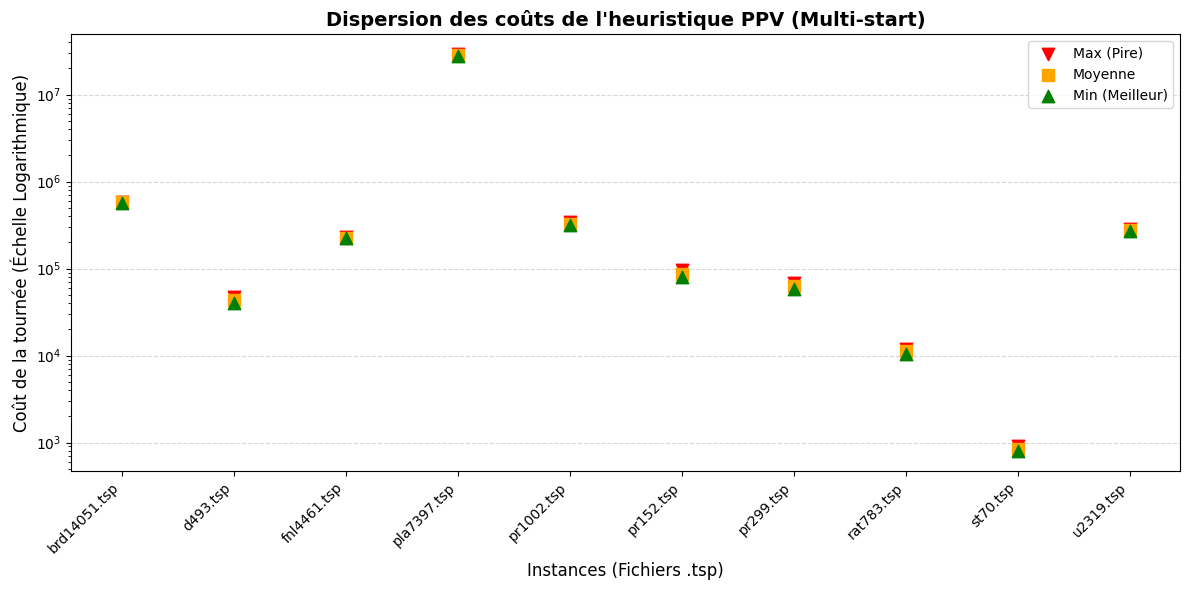

In [21]:
import matplotlib.pyplot as plt

# GRAPHIQUE : DISPERSION DES COÛTS (MIN / MOYENNE / MAX)

# On récupère les noms et les statistiques depuis resultats_t3
noms_instances = list(resultats_t3.keys())
mins = [stats[0] for stats in resultats_t3.values()]
maxs = [stats[1] for stats in resultats_t3.values()]
moyennes = [stats[2] for stats in resultats_t3.values()]

plt.figure(figsize=(12, 6))

# On dessine les points pour chaque instance
for i, nom in enumerate(noms_instances):
    # Ligne qui relie le Min et le Max (pour montrer l'écart)
    plt.plot([i, i], [mins[i], maxs[i]], color='gray', linestyle='--', zorder=1)
    
    # Points pour Max, Moyenne et Min
    plt.scatter(i, maxs[i], color='red', marker='v', s=80, label='Max (Pire)' if i==0 else "", zorder=2)
    plt.scatter(i, moyennes[i], color='orange', marker='s', s=80, label='Moyenne' if i==0 else "", zorder=2)
    plt.scatter(i, mins[i], color='green', marker='^', s=80, label='Min (Meilleur)' if i==0 else "", zorder=2)

# ÉCHELLE LOGARITHMIQUE : Indispensable car les instances ont des tailles très différentes !
plt.yscale('log')

# Mise en forme du graphique
plt.xticks(range(len(noms_instances)), noms_instances, rotation=45, ha='right')
plt.title("Dispersion des coûts de l'heuristique PPV (Multi-start)", fontsize=14, fontweight='bold')
plt.ylabel("Coût de la tournée (Échelle Logarithmique)", fontsize=12)
plt.xlabel("Instances (Fichiers .tsp)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Affichage
plt.show()

<div class="alert alert-block alert-success">
    <h3> Étape 2.4 — Bilan comparatif de l'Heuristique PPV</h3><br>
    Avant de passer aux métaheuristiques, nous faisons le bilan de nos trois approches pour l'algorithme du Plus Proche Voisin (en récupérant les données déjà calculées précédemment) :<br>
    <ul>
        <li><b>Départ Fixe (Ville 6)</b></li>
        <li><b>Départ Aléatoire</b></li>
        <li><b>Multi-start</b></li>
    </ul>
    Ce tableau comparatif met en évidence les différents coûts obtenus. Étant donné que le Multi-start ne teste qu'un échantillon de 100 villes pour les très grandes instances, nous allons comparer strictement les trois résultats pour extraire la <b>meilleure tournée absolue</b> pour chaque instance.<br><br>
    C'est cette tournée optimale (notre record absolu PPV) qui sera conservée en mémoire et servira de point de départ ("Warm Start") pour initialiser le Recuit Simulé dans la Partie 3.
</div>

In [22]:
# Ce dictionnaire va stocker LA VRAIE meilleure tournée parmi les 3 méthodes
meilleures_tournees_absolues = {}

# TABLEAU 1 : COMPARAISON DES 3 MÉTHODES DE DÉPART (PPV)

print("BILAN PARTIE 2 : COMPARAISON DES 3 MÉTHODES DE DÉPART (PPV)\n")
print(f"{'Instance':<15} | {'Coût Fixe (V6)':<15} | {'Coût Aléatoire':<15} | {'Coût Multi-start':<18} | {'Meilleur Absolu':<15}")
print("=" * 86)

for filename, matrice in matrices_distances.items():
    # 1. On récupère les 3 tournées
    tournee_fixe = tournees_sauvegardees[filename]
    tournee_alea = tournees_sauvegardees_alea[filename]
    tournee_multi = resultats_t2[filename]
    
    # 2. On calcule/récupère les 3 coûts
    cout_fixe = calculer_cout(tournee_fixe, matrice)
    cout_alea = calculer_cout(tournee_alea, matrice)
    cout_multi = resultats_t1[filename][2]
    
    # 3. On cherche la VRAIE meilleure tournée parmi les 3
    meilleur_cout = cout_fixe
    meilleure_tournee = tournee_fixe
    
    if cout_alea < meilleur_cout:
        meilleur_cout = cout_alea
        meilleure_tournee = tournee_alea
        
    if cout_multi < meilleur_cout:
        meilleur_cout = cout_multi
        meilleure_tournee = tournee_multi
        
    # On sauvegarde la tournée VRAIMENT gagnante pour le Recuit Simulé
    meilleures_tournees_absolues[filename] = meilleure_tournee
    
    # Affichage
    print(f"{filename:<15} | {cout_fixe:<15.2f} | {cout_alea:<15.2f} | {cout_multi:<18.2f} | {meilleur_cout:<15.2f}")

BILAN PARTIE 2 : COMPARAISON DES 3 MÉTHODES DE DÉPART (PPV)

Instance        | Coût Fixe (V6)  | Coût Aléatoire  | Coût Multi-start   | Meilleur Absolu
brd14051.tsp    | 584252.00       | 580482.00       | 572574.00          | 572574.00      
d493.tsp        | 41871.00        | 43999.00        | 40186.00           | 40186.00       
fnl4461.tsp     | 222020.00       | 225026.00       | 221767.00          | 221767.00      
pla7397.tsp     | 28540096.00     | 28059761.00     | 27964226.00        | 27964226.00    
pr1002.tsp      | 336133.00       | 319883.00       | 315383.00          | 315383.00      
pr152.tsp       | 87798.00        | 86109.00        | 79564.00           | 79564.00       
pr299.tsp       | 60082.00        | 60588.00        | 58279.00           | 58279.00       
rat783.tsp      | 11122.00        | 11233.00        | 10540.00           | 10540.00       
st70.tsp        | 833.00          | 832.00          | 796.00             | 796.00         
u2319.tsp       | 278897.00  

In [23]:
# TABLEAU 2 : LA TOURNÉE DÉFINITIVE 

print(f"{'Instance':<15} | {'Tournée Définitive (Record Absolu PPV)'}")
print("=" * 100)

# On affiche LA tournée gagnante
for filename, tournee in meilleures_tournees_absolues.items():
    tournee_texte = str(tournee)
    lignes_decoupees = textwrap.wrap(tournee_texte, width=80)
    
    # Affichage propre
    print(f"{filename:<15} | {lignes_decoupees[0]}")
    for ligne in lignes_decoupees[1:]:
        print(f"{'':<15} | {ligne}")
        
    print("-" * 100)

Instance        | Tournée Définitive (Record Absolu PPV)
brd14051.tsp    | [10547, 10533, 10410, 10343, 10333, 10261, 10231, 10192, 10066, 10054, 10158,
                | 10131, 10088, 10189, 10226, 10086, 9970, 9763, 9606, 9512, 9421, 9448, 9442,
                | 9566, 9607, 9753, 9804, 9921, 9973, 9895, 9998, 10062, 9861, 9922, 9723, 9596,
                | 9531, 9481, 9373, 9475, 9675, 9530, 9403, 9396, 9187, 9170, 9045, 9298, 9417,
                | 9680, 10084, 10278, 10279, 10244, 10124, 10145, 10208, 10125, 10139, 10018,
                | 9812, 9714, 9669, 9532, 9499, 9359, 9328, 9271, 9188, 9126, 9061, 8966, 8859,
                | 9006, 9019, 9127, 9149, 9232, 9243, 9139, 8891, 8771, 8634, 8406, 8323, 8202,
                | 8151, 7948, 8032, 8111, 7907, 7868, 7801, 7883, 7779, 7862, 7899, 7925, 7888,
                | 7944, 7802, 7735, 7613, 7585, 7394, 7347, 7264, 7165, 7174, 7088, 7098, 7219,
                | 7205, 7311, 7402, 7532, 7632, 7641, 7569, 7495, 7419, 7325, 746

<h2 style="color: #2980b9;">Partie 3 : Métaheuristiques - Recherche Tabou</h2>

<div class="alert alert-block alert-info">
    Contrairement à un algorithme glouton qui s'arrête au premier optimum local rencontré, la recherche Tabou autorise des mouvements qui dégradent temporairement la solution pour s'échapper des "vallées". Pour éviter de tourner en boucle, elle utilise une <b>liste Tabou</b> qui mémorise et interdit les mouvements récemment effectués.
    <br><br>
    <i>Note : Le code source optimisé de notre algorithme se trouve dans le fichier externe <code>metaheuristique.py</code> pour garder ce notebook propre. Notre critère d'arrêt sera basé sur la <b>stagnation</b> plutôt que sur un temps fixe.</i>

Dans cette section, nous allons procéder à une démarche expérimentale rigoureuse en isolant chaque composante de l'algorithme :

1. **L'Initialisation (Point de départ) :** Test des stratégies Warm Start, Cold Start et Canonique.
2. **Les Structures de Voisinage :** Nous testerons 3 approches différentes :
   * *2-opt Aléatoire Classique* : Tirage aléatoire de deux arêtes n'importe où.
   * *2-opt Spatial (K-voisins)* : Restriction des croisements aux villes géographiquement proches.
   * *Échange de Nœuds (Swap)* : Permutation de deux villes au lieu de l'inversion d'un segment.
3. **Le Paramétrage :** Ajustement de la taille de la liste tabou et du critère de stagnation.
</div>
<div class="alert alert-block alert-success">
    <h3>Étape 3.1 — L'impact de l'Initialisation</h3><br>
    La qualité et la rapidité de convergence d'une métaheuristique dépendent fortement de son point de départ. Nous allons tester l'algorithme Tabou avec trois initialisations différentes :
    <ol>
        <li><b>Warm Start (Démarrage à chaud) </b> 
        <li><b>Cold Start (Démarrage à froid) </b> </li>
        <li><b>Canonique</b> </li>
    </ol>
</div>

<div class="alert alert-block alert-warning">
    <h3>1) Warm Start</h3><br>
     L'algorithme démarre avec une solution déjà de bonne qualité, générée par une heuristique préalable (ici, notre algorithme du Plus Proche Voisin). Cela donne une forte longueur d'avance à la recherche.</li>
</div>

In [31]:
# Création sécurisée de la liste triée (évite l'erreur NameError)
instances_triees = sorted(matrices_distances.keys(), key=lambda x: matrices_distances[x].shape[0])

STAGNATION_MAX = 1000  

# Dictionnaire pour stocker les résultats et faire la comparaison à la fin
resultats_dynamiques = {}
for f in instances_triees:
    resultats_dynamiques[f] = {}


# TABLEAU 1 : WARM START (PPV)
print(" RÉSULTATS : WARM START (Initialisation PPV depuis Partie 2)\n")
print(f"{'Instance':<15} | {'Coût Init (Warm)':<18} | {'Aperçu Tournée Finale':<35} | {'Valide':<8} | {'Coût Final Tabou':<18} | {'Temps (s)':<10}")
print("=" * 115)

for filename in instances_triees:
    matrice = matrices_distances[filename]
    n_villes = matrice.shape[0]
    tournee_warm = meilleures_tournees_absolues[filename] 
    cout_warm = calculer_cout(tournee_warm, matrice)
    
    tournee_fin_warm, cout_fin_warm, t_warm = recherche_tabou(matrice, tournee_warm, cout_warm, type_voisinage='spatial', max_stagnation=STAGNATION_MAX)
    
    # Sauvegarde pour la comparaison
    resultats_dynamiques[filename]['Warm'] = (cout_fin_warm, tournee_fin_warm, t_warm)    
    est_valide = verifier_tournee(tournee_fin_warm, n_villes)
    statut_valide = "Oui" if est_valide else "Non"
    
    if len(tournee_fin_warm) >= 5:
        apercu = f"[{', '.join(map(str, tournee_fin_warm[:3]))} ... {', '.join(map(str, tournee_fin_warm[-2:]))}]"
    else:
        apercu = f"[{', '.join(map(str, tournee_fin_warm))}]"
        
    print(f"{filename:<15} | {cout_warm:<18.2f} | {apercu:<35} | {statut_valide:<8} | {cout_fin_warm:<18.2f} | {t_warm:<10.2f}")

 RÉSULTATS : WARM START (Initialisation PPV depuis Partie 2)

Instance        | Coût Init (Warm)   | Aperçu Tournée Finale               | Valide   | Coût Final Tabou   | Temps (s) 
st70.tsp        | 796.00             | [64, 11, 67 ... 56, 65]             | Oui      | 695.00             | 2.00      
pr152.tsp       | 79564.00           | [45, 54, 69 ... 18, 40]             | Oui      | 76060.00           | 0.85      
pr299.tsp       | 58279.00           | [155, 156, 146 ... 153, 154]        | Oui      | 50623.00           | 2.39      
d493.tsp        | 40186.00           | [6, 5, 4 ... 7, 8]                  | Oui      | 37447.00           | 1.45      
rat783.tsp      | 10540.00           | [356, 359, 352 ... 384, 363]        | Oui      | 9390.00            | 2.03      
pr1002.tsp      | 315383.00          | [95, 96, 97 ... 136, 76]            | Oui      | 277182.00          | 1.71      
u2319.tsp       | 270418.00          | [2250, 2249, 2244 ... 2251, 2252]   | Oui      | 240934.00 

<div class="alert alert-block alert-warning">
    <h3>2) Cold Start</h3><br>
  L'algorithme démarre avec une tournée générée de manière totalement aléatoire. La recherche part de zéro et doit explorer l'espace des solutions sans aucune information préalable.</li>
</div>

In [34]:
# TABLEAU 2 : COLD START (Aléatoire)
STAGNATION_MAX = 500  

print("\n\n RÉSULTATS : COLD START (Départ Aléatoire) \n")
print(f"{'Instance':<15} | {'Coût Init (Cold)':<18} | {'Aperçu Tournée Finale':<37} | {'Valide':<8} | {'Coût Final Tabou':<18} | {'Temps (s)':<10}")
print("=" * 115)

for filename in instances_triees:
    matrice = matrices_distances[filename]
    n_villes = matrice.shape[0]
    
    tournee_cold = list(range(1, n_villes + 1))
    random.shuffle(tournee_cold)
    cout_cold = calculer_cout(tournee_cold, matrice)
    
    tournee_fin_cold, cout_fin_cold, t_cold = recherche_tabou(matrice, tournee_cold, cout_cold, type_voisinage='spatial', max_stagnation=STAGNATION_MAX)
    
    # Sauvegarde pour la comparaison
    resultats_dynamiques[filename]['Cold'] = (cout_fin_cold, tournee_fin_cold)
    
    est_valide = verifier_tournee(tournee_fin_cold, n_villes)
    statut_valide = "Oui" if est_valide else "Non"
    
    if len(tournee_fin_cold) >= 5:
        apercu = f"[{', '.join(map(str, tournee_fin_cold[:3]))} ... {', '.join(map(str, tournee_fin_cold[-2:]))}]"
    else:
        apercu = f"[{', '.join(map(str, tournee_fin_cold))}]"
        
    print(f"{filename:<15} | {cout_cold:<18.2f} | {apercu:<37} | {statut_valide:<8} | {cout_fin_cold:<18.2f} | {t_cold:<10.2f}")



 RÉSULTATS : COLD START (Départ Aléatoire) 

Instance        | Coût Init (Cold)   | Aperçu Tournée Finale                 | Valide   | Coût Final Tabou   | Temps (s) 
st70.tsp        | 3581.00            | [34, 21, 12 ... 54, 62]               | Oui      | 692.00             | 0.40      
pr152.tsp       | 1051627.00         | [35, 48, 36 ... 1, 49]                | Oui      | 757771.00          | 2.00      
pr299.tsp       | 767510.00          | [74, 71, 29 ... 72, 73]               | Oui      | 53672.00           | 4.00      
d493.tsp        | 454114.00          | [456, 486, 480 ... 455, 442]          | Oui      | 41924.00           | 5.53      
rat783.tsp      | 181559.00          | [370, 377, 393 ... 391, 372]          | Oui      | 9744.00            | 5.78      
pr1002.tsp      | 6446571.00         | [797, 796, 795 ... 808, 798]          | Oui      | 653869.00          | 18.81     
u2319.tsp       | 5980977.00         | [2082, 2095, 2093 ... 2091, 2087]     | Oui      | 243191.00

<div class="alert alert-block alert-warning">
    <h3>3) Avec une tournée canonique</h3><br>
    L'algorithme démarre avec l'ordre séquentiel basique des villes (1, 2, 3, ..., N). C'est un point de départ naïf et déterministe qui sert de point de repère absolu.</li>
</div>

In [35]:
# TABLEAU 3 : CANONIQUE (1, 2, ..., N)
print("\n\n RÉSULTATS : CANONIQUE (Ordre séquentiel) \n")
print(f"{'Instance':<15} | {'Coût Init (Cano)':<18} | {'Aperçu Tournée Finale':<37} | {'Valide':<8} | {'Coût Final Tabou':<18} | {'Temps (s)':<10}")
print("=" * 115)

for filename in instances_triees:
    matrice = matrices_distances[filename]
    n_villes = matrice.shape[0]
    
    tournee_canon = list(range(1, n_villes + 1))
    cout_canon = calculer_cout(tournee_canon, matrice)
    
    tournee_fin_canon, cout_fin_canon, t_canon = recherche_tabou(matrice, tournee_canon, cout_canon, type_voisinage='spatial', max_stagnation=STAGNATION_MAX)
    
    # Sauvegarde pour la comparaison
    resultats_dynamiques[filename]['Canonique'] = (cout_fin_canon, tournee_fin_canon)
    
    est_valide = verifier_tournee(tournee_fin_canon, n_villes)
    statut_valide = "Oui" if est_valide else "Non"
    
    if len(tournee_fin_canon) >= 5:
        apercu = f"[{', '.join(map(str, tournee_fin_canon[:3]))} ... {', '.join(map(str, tournee_fin_canon[-2:]))}]"
    else:
        apercu = f"[{', '.join(map(str, tournee_fin_canon))}]"
        
    print(f"{filename:<15} | {cout_canon:<18.2f} | {apercu:<37} | {statut_valide:<8} | {cout_fin_canon:<18.2f} | {t_canon:<10.2f}")



 RÉSULTATS : CANONIQUE (Ordre séquentiel) 

Instance        | Coût Init (Cano)   | Aperçu Tournée Finale                 | Valide   | Coût Final Tabou   | Temps (s) 
st70.tsp        | 3410.00            | [47, 16, 36 ... 58, 37]               | Oui      | 692.00             | 0.47      
pr152.tsp       | 160980.00          | [34, 35, 36 ... 125, 124]             | Oui      | 83162.00           | 0.68      
pr299.tsp       | 83506.00           | [7, 8, 9 ... 5, 92]                   | Oui      | 53573.00           | 1.21      
d493.tsp        | 113543.00          | [1, 2, 3 ... 468, 467]                | Oui      | 39114.00           | 3.83      
rat783.tsp      | 72134.00           | [464, 494, 521 ... 469, 467]          | Oui      | 9577.00            | 3.76      
pr1002.tsp      | 349403.00          | [538, 535, 533 ... 831, 832]          | Oui      | 285394.00          | 2.51      
u2319.tsp       | 281496.00          | [38, 42, 43 ... 40, 41]               | Oui      | 242436.00 

<div class="alert alert-block alert-warning">
    <h3> 4) Synthèse et Comparaison des Initialisations</h3><br>
    Maintenant que nous avons évalué l'algorithme Tabou avec trois points de départ différents, nous allons confronter leurs coûts finaux. <br>
    L'objectif est de déterminer quelle méthode d'initialisation permet à la Recherche Tabou d'atteindre la meilleure solution (le coût le plus bas).<br>
    Pour chaque instance, nous affichons ci-dessous la tournée complète générée par la méthode d'initialisation gagnante. <br>
</div>

In [36]:
# TABLEAU 4 : COMPARAISON DES COÛTS FINAUX
print("\n\n SYNTHÈSE : COMPARAISON DES INITIALISATIONS \n")
print(f"{'Instance':<15} | {'Méthode Gagnante':<18} | {'Coût Warm':<14} | {'Coût Cold':<14} | {'Coût Canonique':<14}")
print("=" * 85)

for filename in instances_triees:
    couts_instance = resultats_dynamiques[filename]
    
    # min() trouve la clé ('Warm', 'Cold', 'Canonique') qui a le coût le plus bas (index 0)
    methode_gagnante = min(couts_instance, key=lambda k: couts_instance[k][0])
    
    cout_w = couts_instance['Warm'][0]
    cout_c = couts_instance['Cold'][0]
    cout_can = couts_instance['Canonique'][0]
    
    print(f"{filename:<15} | {methode_gagnante:<18} | {cout_w:<14.2f} | {cout_c:<14.2f} | {cout_can:<14.2f}")
print("-" * 85)



 SYNTHÈSE : COMPARAISON DES INITIALISATIONS 

Instance        | Méthode Gagnante   | Coût Warm      | Coût Cold      | Coût Canonique
st70.tsp        | Cold               | 695.00         | 692.00         | 692.00        
pr152.tsp       | Warm               | 76060.00       | 757771.00      | 83162.00      
pr299.tsp       | Warm               | 50623.00       | 53672.00       | 53573.00      
d493.tsp        | Warm               | 37447.00       | 41924.00       | 39114.00      
rat783.tsp      | Warm               | 9390.00        | 9744.00        | 9577.00       
pr1002.tsp      | Warm               | 277182.00      | 653869.00      | 285394.00     
u2319.tsp       | Warm               | 240934.00      | 243191.00      | 242436.00     
fnl4461.tsp     | Warm               | 196055.00      | 237504.00      | 234433.00     
pla7397.tsp     | Cold               | 25710763.00    | -2147477880.00 | 92635205.00   
brd14051.tsp    | Warm               | 506905.00      | 2101604.00     |

In [48]:
# TABLEAU 5 : DÉTAIL DES MEILLEURES TOURNÉES 
print("\n\n DÉTAIL DES MEILLEURES TOURNÉES COMPLÈTES \n")
print(f"{'Instance':<12} | {'Méthode Gagnante':<18} | {'Coût Final':<15} | {'Tournée Complète'}")
print("=" * 115)

for filename in instances_triees:
    # Vérifier si l'instance existe dans les résultats
    if filename not in resultats_dynamiques:
        continue
        
    couts_instance = resultats_dynamiques[filename]
    
    # Trouver la méthode qui a le coût minimum (l'élément à l'index 0)
    meilleure_methode = min(couts_instance, key=lambda k: couts_instance[k][0])
    
    # CORRECTION ICI : extraction sécurisée
    donnees = couts_instance[meilleure_methode]
    meilleur_cout = donnees[0]
    meilleure_tournee = donnees[1]
    
    tournee_texte = str(meilleure_tournee)
    lignes_decoupees = textwrap.wrap(tournee_texte, width=55)
    
    # Affichage de la première ligne
    print(f"{filename:<12} | {meilleure_methode:<18} | {meilleur_cout:<15.2f} | {lignes_decoupees[0]}")
    
    # Affichage des lignes suivantes de la tournée pour l'alignement
    for ligne in lignes_decoupees[1:]:
        print(f"{'':<12} | {'':<18} | {'':<15} | {ligne}")
    print("-" * 115)



 DÉTAIL DES MEILLEURES TOURNÉES COMPLÈTES 

Instance     | Méthode Gagnante   | Coût Final      | Tournée Complète
st70.tsp     | Cold               | 692.00          | [34, 21, 12, 33, 60, 52, 10, 5, 53, 6, 41, 43, 17, 9,
             |                    |                 | 40, 61, 39, 25, 45, 46, 27, 68, 44, 30, 20, 14, 28, 8,
             |                    |                 | 55, 49, 26, 3, 32, 42, 18, 4, 2, 7, 19, 15, 24, 57, 66,
             |                    |                 | 22, 63, 59, 35, 69, 31, 29, 70, 13, 38, 23, 1, 36, 16,
             |                    |                 | 47, 37, 58, 50, 51, 56, 65, 64, 11, 67, 48, 54, 62]
-------------------------------------------------------------------------------------------------------------------
pr152.tsp    | Warm               | 76060.00        | [45, 54, 69, 70, 71, 46, 52, 53, 72, 79, 97, 98, 99,
             |                    |                 | 90, 80, 114, 113, 100, 89, 81, 68, 55, 44, 56, 67, 66,
         

<div class="alert alert-block alert-success">
    <h3>Étape 3.2 — Test des Structures de Voisinage</h3><br>
    Maintenant que nous avons confirmé que le <b>Warm Start</b> est de loin le meilleur point de départ, nous allons l'utiliser comme base pour tester trois types de mouvements (voisinages) différents pour notre Recherche Tabou. <br><br>
    <i> <b>Note :</b> L'implémentation détaillée de ces fonctions de voisinage se trouve dans le fichier <code>metaheuristiques.py</code>.</i>
    <ol>
        <li><b>2-opt Spatial ('spatial') :</b> Inversion d'un segment uniquement entre des villes géographiquement proches (les K plus proches voisins).</li>
        <li><b>2-opt Aléatoire ('aleatoire') :</b> Inversion d'un segment en tirant deux arêtes complètement au hasard.</li>
        <li><b>Swap de Nœuds ('swap') :</b> Permutation stricte de la position de deux villes sans inverser le reste du chemin.</li>
    </ol>
</div>

In [38]:
# COMPARAISON DES VOISINAGES
print(" COMPARAISON DES VOISINAGES (Initialisation : Warm Start) \n")
# En-tête du tableau (adapté pour inclure Voisinage, Aperçu et Validité)
print(f"{'':<14} | {'Voisinage':<10} | {'Coût Init':<12} | {'Aperçu Tournée Finale':<35} | {'Valide':<6} | {'Coût Final':<12} | {'Temps (s)':<9}")
print("=" * 105)

STAGNATION_VOISINAGE = 500 # Stagnation réduite pour accélérer le test
types_voisinages = ['spatial', 'aleatoire', 'swap']

# Dictionnaire pour sauvegarder TOUTES les tournées
tournees_finales_voisinages = {}

for filename in instances_triees:
    matrice = matrices_distances[filename]
    n_villes = matrice.shape[0]
    tournee_warm = meilleures_tournees_absolues[filename] 
    cout_warm = calculer_cout(tournee_warm, matrice)
    
    tournees_finales_voisinages[filename] = {}
    
    # Affichage du nom de l'instance bien mis en évidence
    print(f"▶ {filename.upper()} (Villes: {n_villes})")
    
    for voisinage in types_voisinages:
        # Exécution de la recherche tabou avec le voisinage spécifique
        tournee_fin, cout_fin, t_exec = recherche_tabou(
            matrice_dist=matrice, 
            tournee_initiale=tournee_warm, 
            cout_initial=cout_warm, 
            type_voisinage=voisinage, 
            max_stagnation=STAGNATION_VOISINAGE
        )
        
        tournees_finales_voisinages[filename][voisinage] = tournee_fin
        
        #  Calcul de la validité
        est_valide = verifier_tournee(tournee_fin, n_villes)
        statut_valide = "Oui" if est_valide else "Non"
        
        # Génération de l'aperçu (3 premières ... 2 dernières)
        if len(tournee_fin) >= 5:
            apercu = f"[{', '.join(map(str, tournee_fin[:3]))} ... {', '.join(map(str, tournee_fin[-2:]))}]"
        else:
            apercu = f"[{', '.join(map(str, tournee_fin))}]"
        
        # Affichage de la ligne décalée (la première colonne est vide pour l'indentation)
        print(f"{'':<14} | {voisinage:<10} | {cout_warm:<12.2f} | {apercu:<35} | {statut_valide:<6} | {cout_fin:<12.2f} | {t_exec:<9.2f}")
        
    print("-" * 105)

 COMPARAISON DES VOISINAGES (Initialisation : Warm Start) 

               | Voisinage  | Coût Init    | Aperçu Tournée Finale               | Valide | Coût Final   | Temps (s)
▶ ST70.TSP (Villes: 70)
               | spatial    | 796.00       | [46, 27, 30 ... 45, 25]             | Oui    | 688.00       | 0.21     
               | aleatoire  | 796.00       | [49, 55, 26 ... 28, 8]              | Oui    | 780.00       | 0.42     
               | swap       | 796.00       | [43, 17, 41 ... 14, 44]             | Oui    | 782.00       | 2.87     
---------------------------------------------------------------------------------------------------------
▶ PR152.TSP (Villes: 152)
               | spatial    | 79564.00     | [45, 54, 69 ... 18, 40]             | Oui    | 75957.00     | 0.40     
               | aleatoire  | 79564.00     | [45, 54, 69 ... 18, 40]             | Oui    | 79564.00     | 0.40     
               | swap       | 79564.00     | [45, 54, 69 ... 18, 40]             |

<div class="alert alert-block alert-warning">
    <h3>Synthèse : Quel est le meilleur voisinage ?</h3><br>
    Suite à l'exécution précédente, nous allons extraire pour chaque instance testée le mouvement (voisinage) qui a permis d'obtenir le coût le plus bas. Cela nous permettra de fixer ce paramètre pour la suite de nos expériences.
</div>

In [39]:
# SYNTHÈSE : LE MEILLEUR VOISINAGE PAR INSTANCE
print(" LES MEILLEURS VOISINAGES \n")
print(f"{'Instance':<15} | {'Voisinage Gagnant':<18} | {'Coût Minimum':<15}")
print("=" * 55)

# Dictionnaire pour garder en mémoire le meilleur voisinage pour l'étape 3.3
meilleurs_voisinages_par_instance = {}

for filename in instances_triees:
    matrice = matrices_distances[filename]
    
    meilleur_voisinage = None
    meilleur_cout = float('inf')
    
    # On parcourt les tournées sauvegardées pour trouver la moins chère
    for voisinage, tournee in tournees_finales_voisinages[filename].items():
        cout_actuel = calculer_cout(tournee, matrice)
        if cout_actuel < meilleur_cout:
            meilleur_cout = cout_actuel
            meilleur_voisinage = voisinage
            
    meilleurs_voisinages_par_instance[filename] = meilleur_voisinage
    print(f"{filename:<15} | {meilleur_voisinage:<18} | {meilleur_cout:<15.2f}")

print("-" * 55)

 LES MEILLEURS VOISINAGES 

Instance        | Voisinage Gagnant  | Coût Minimum   
st70.tsp        | spatial            | 688.00         
pr152.tsp       | spatial            | 75957.00       
pr299.tsp       | spatial            | 52634.00       
d493.tsp        | spatial            | 37789.00       
rat783.tsp      | spatial            | 9454.00        
pr1002.tsp      | spatial            | 277140.00      
u2319.tsp       | spatial            | 240775.00      
fnl4461.tsp     | spatial            | 197762.00      
pla7397.tsp     | spatial            | 25824330.00    
brd14051.tsp    | spatial            | 512162.00      
-------------------------------------------------------


<div class="alert alert-block alert-success">
    <h3>Étape 3.3 — Paramétrage de la Recherche Tabou</h3><br>
    Maintenant que nous avons identifié la meilleure initialisation (<b>Warm Start</b>) et le meilleur voisinage, nous allons ajuster les hyperparamètres de l'algorithme :
    <ul>
        <li><b>La taille de la liste tabou :</b> Une liste trop petite crée des cycles (on tourne en rond), une liste trop grande bride l'exploration (on s'enferme). Nous allons tester différentes tailles (ex: 10, 25, 50, 100).</li>
        <li><b>Le nombre de voisins (K) :</b> Définit la taille de l'espace de recherche lors d'un mouvement spatial. Un $K$ élevé permet d'explorer plus de solutions potentielles, mais augmente le temps de calcul.</li>
    </ul>
</div>

In [40]:
# TEST DES TAILLES DE LISTE TABOU
print(" TEST DU PARAMÉTRAGE : TAILLE DE LA LISTE TABOU \n")
print(f"{'':<14} | {'Taille Tabou':<15} | {'Coût Final':<15} | {'Temps (s)':<10}")
print("=" * 65)

tailles_a_tester = [10, 25, 50, 100]
STAGNATION_PARAM = 500 # Fixé pour comparer équitablement

# Dictionnaire pour stocker les résultats de cette phase
resultats_parametrage = {}

for filename in instances_triees:
    matrice = matrices_distances[filename]
    tournee_warm = meilleures_tournees_absolues[filename] 
    cout_warm = calculer_cout(tournee_warm, matrice)
    
    # On récupère le voisinage gagnant trouvé à l'étape précédente
    # Si pour une raison quelconque il n'est pas défini, on force 'spatial' par défaut
    voisinage_opti = meilleurs_voisinages_par_instance.get(filename, 'spatial')
    
    resultats_parametrage[filename] = {}
    
    print(f"▶ {filename.upper()} (Voisinage: {voisinage_opti})")
    
    for taille in tailles_a_tester:
        # Exécution avec la taille de liste tabou spécifique
        tournee_fin, cout_fin, t_exec = recherche_tabou(
            matrice_dist=matrice, 
            tournee_initiale=tournee_warm, 
            cout_initial=cout_warm, 
            type_voisinage=voisinage_opti, 
            max_stagnation=STAGNATION_PARAM,
            taille_tabou=taille 
        )
        
        # Sauvegarde (on garde le coût et le temps pour la comparaison)
        resultats_parametrage[filename][taille] = (cout_fin, t_exec)
        
        print(f"{'':<14} | Tabou = {taille:<7} | {cout_fin:<15.2f} | {t_exec:<10.2f}")
        
    print("-" * 65)

 TEST DU PARAMÉTRAGE : TAILLE DE LA LISTE TABOU 

               | Taille Tabou    | Coût Final      | Temps (s) 
▶ ST70.TSP (Voisinage: spatial)
               | Tabou = 10      | 694.00          | 0.44      
               | Tabou = 25      | 702.00          | 0.81      
               | Tabou = 50      | 708.00          | 0.40      
               | Tabou = 100     | 744.00          | 0.49      
-----------------------------------------------------------------
▶ PR152.TSP (Voisinage: spatial)
               | Tabou = 10      | 75670.00        | 0.50      
               | Tabou = 25      | 76146.00        | 0.66      
               | Tabou = 50      | 76577.00        | 0.38      
               | Tabou = 100     | 77267.00        | 0.50      
-----------------------------------------------------------------
▶ PR299.TSP (Voisinage: spatial)
               | Tabou = 10      | 51071.00        | 1.53      
               | Tabou = 25      | 50707.00        | 1.24      
               |

In [44]:
# TEST DU PARAMÈTRE : NOMBRE DE VOISINS (K)
print(" TEST DU PARAMÉTRAGE : NOMBRE DE VOISINS (K) \n")
print(f"{'':<14} | {'K Voisins':<15} | {'Coût Final':<15} | {'Temps (s)':<10}")
print("=" * 65)

k_a_tester = [5, 10, 15, 30, 50]

# Dictionnaire pour stocker les résultats
resultats_k_voisins = {}

for filename in instances_triees:
    matrice = matrices_distances[filename]
    tournee_warm = meilleures_tournees_absolues[filename] 
    cout_warm = calculer_cout(tournee_warm, matrice)
    
    # On récupère automatiquement la meilleure taille tabou trouvée juste au-dessus !
    couts_par_taille = resultats_parametrage[filename]
    meilleure_taille = min(couts_par_taille, key=lambda t: couts_par_taille[t][0])
    
    resultats_k_voisins[filename] = {}
    
    print(f"▶ {filename.upper()} (Taille Tabou fixée à: {meilleure_taille})")
    
    for k in k_a_tester:
        # Exécution en forçant le voisinage 'spatial' et en utilisant le meilleur tabou
        tournee_fin, cout_fin, t_exec = recherche_tabou(
            matrice_dist=matrice, 
            tournee_initiale=tournee_warm, 
            cout_initial=cout_warm, 
            type_voisinage='spatial', 
            max_stagnation=STAGNATION_PARAM,
            taille_tabou=meilleure_taille,
            K_voisins=k 
        )
        
        resultats_k_voisins[filename][k] = (cout_fin, t_exec)
        print(f"{'':<14} | K = {k:<11} | {cout_fin:<15.2f} | {t_exec:<10.2f}")
        
    print("-" * 65)

 TEST DU PARAMÉTRAGE : NOMBRE DE VOISINS (K) 

               | K Voisins       | Coût Final      | Temps (s) 
▶ ST70.TSP (Taille Tabou fixée à: 10)
               | K = 5           | 705.00          | 0.56      
               | K = 10          | 696.00          | 0.46      
               | K = 15          | 697.00          | 0.49      
               | K = 30          | 703.00          | 0.98      
               | K = 50          | 732.00          | 0.60      
-----------------------------------------------------------------
▶ PR152.TSP (Taille Tabou fixée à: 10)
               | K = 5           | 75409.00        | 0.94      
               | K = 10          | 75909.00        | 0.88      
               | K = 15          | 75275.00        | 0.90      
               | K = 30          | 77227.00        | 0.81      
               | K = 50          | 77563.00        | 0.40      
-----------------------------------------------------------------
▶ PR299.TSP (Taille Tabou fixée à: 25)
 

<div class="alert alert-block alert-warning">
    <h3>Synthèse du Paramétrage </h3><br>
    Quel est le meilleur compromis final pour notre algorithme ? Affichons pour chaque instance la combinaison idéale entre la <b>taille de liste Tabou</b> et le <b>nombre de voisins (K)</b> qui a donné le coût minimum.
</div>

In [45]:
# SYNTHÈSE GLOBALE : LE MEILLEUR PARAMÉTRAGE

print(" MEILLEURS PARAMÈTRES (TAILLE TABOU & K VOISINS) \n")
print(f"{'Instance':<15} | {'Taille Tabou':<16} | {'K Idéal':<12} | {'Coût Final':<15}")
print("=" * 65)

for filename in instances_triees:
    # 1. Identifier la meilleure taille tabou
    couts_par_taille = resultats_parametrage[filename]
    meilleure_taille = min(couts_par_taille, key=lambda k: couts_par_taille[k][0])
    
    # 2. Identifier le meilleur K
    couts_par_k = resultats_k_voisins[filename]
    meilleur_k = min(couts_par_k, key=lambda k: couts_par_k[k][0])
    meilleur_cout = couts_par_k[meilleur_k][0]
    
    print(f"{filename:<15} | Tabou = {meilleure_taille:<8} | K = {meilleur_k:<8} | {meilleur_cout:<15.2f}")

print("-" * 65)

 MEILLEURS PARAMÈTRES (TAILLE TABOU & K VOISINS) 

Instance        | Taille Tabou     | K Idéal      | Coût Final     
st70.tsp        | Tabou = 10       | K = 10       | 696.00         
pr152.tsp       | Tabou = 10       | K = 15       | 75275.00       
pr299.tsp       | Tabou = 25       | K = 10       | 50757.00       
d493.tsp        | Tabou = 50       | K = 15       | 37259.00       
rat783.tsp      | Tabou = 25       | K = 10       | 9384.00        
pr1002.tsp      | Tabou = 25       | K = 15       | 280302.00      
u2319.tsp       | Tabou = 100      | K = 10       | 241787.00      
fnl4461.tsp     | Tabou = 50       | K = 10       | 197910.00      
pla7397.tsp     | Tabou = 50       | K = 10       | 25656302.00    
brd14051.tsp    | Tabou = 25       | K = 10       | 510720.00      
-----------------------------------------------------------------


<h2 style="color: #2980b9;">Partie 4 : Comparaison Heuristique vs Métaheuristique</h2><br>

<div class="alert alert-block alert-info">
    Conformément aux directives du projet, nous allons maintenant comparer les performances de notre heuristique de base (Plus Proche Voisin) avec notre métaheuristique (Recherche Tabou).<br><br>
    Nous allons évaluer le coût final de la tournée et le temps d'exécution. Le critère de comparaison principal est le <b>Gain Relatif</b>, calculé selon la formule officielle du projet :
    $$Gain(\%) = 100 \times \frac{C_{glouton} - C_{m\acute{e}ta}}{C_{glouton}}$$ 
</div>

In [46]:
# TABLEAU DE COMPARAISON : GLOUTON VS TABOU
print(" COMPARAISON FINALE : GLOUTON VS RECHERCHE TABOU \n")
print(f"{'Instance':<15} | {'Coût Glouton':<14} | {'Temps Gl. (s)':<13} | {'Coût Tabou':<14} | {'Temps Tab. (s)':<14} | {'Gain (%)':<10}")
print("=" * 92)

meilleure_instance_globale = None
meilleur_gain_global = -float('inf')
meilleure_tournee_globale = []
meilleur_cout_global = 0

for filename in instances_triees:
    # 1. Récupération des données du Glouton (depuis tes variables de la Partie 2)
    cout_glouton = resultats_t1[filename][2]
    temps_glouton = resultats_t1[filename][3]
    
    # 2. Récupération des données de la Métaheuristique (Meilleur Tabou = Warm Start)
    donnees_tabou = resultats_dynamiques[filename]['Warm']
    cout_tabou = donnees_tabou[0]
    tournee_tabou = donnees_tabou[1]
    temps_tabou = donnees_tabou[2] if len(donnees_tabou) > 2 else 0.0
    
    # 3. Calcul du gain selon la formule du cahier des charges
    gain = 100 * (cout_glouton - cout_tabou) / cout_glouton
    
    # Affichage avec la nouvelle colonne temps_tabou
    print(f"{filename:<15} | {cout_glouton:<14.2f} | {temps_glouton:<13.6f} | {cout_tabou:<14.2f} | {temps_tabou:<14.6f} | {gain:>6.2f} %")
    
    # 4. Identification du record absolu (le plus gros gain)
    if gain > meilleur_gain_global:
        meilleur_gain_global = gain
        meilleure_instance_globale = filename
        meilleure_tournee_globale = tournee_tabou
        meilleur_cout_global = cout_tabou

print("-" * 92)

 COMPARAISON FINALE : GLOUTON VS RECHERCHE TABOU 

Instance        | Coût Glouton   | Temps Gl. (s) | Coût Tabou     | Temps Tab. (s) | Gain (%)  
st70.tsp        | 796.00         | 0.001003      | 695.00         | 2.004135       |  12.69 %
pr152.tsp       | 79564.00       | 0.003002      | 76060.00       | 0.851973       |   4.40 %
pr299.tsp       | 58279.00       | 0.014039      | 50623.00       | 2.390321       |  13.14 %
d493.tsp        | 40186.00       | 0.034445      | 37447.00       | 1.445789       |   6.82 %
rat783.tsp      | 10540.00       | 0.144670      | 9390.00        | 2.025201       |  10.91 %
pr1002.tsp      | 315383.00      | 0.101000      | 277182.00      | 1.709841       |  12.11 %
u2319.tsp       | 270418.00      | 1.009744      | 240934.00      | 3.659127       |  10.90 %
fnl4461.tsp     | 221767.00      | 3.058062      | 196055.00      | 8.386077       |  11.59 %
pla7397.tsp     | 27964226.00    | 9.929252      | 25710763.00    | 10.929788      |   8.06 %
brd1405

In [47]:
# AFFICHAGE DES MEILLEURES TOURNÉES (PPV vs TABOU)
print("\n\n DÉTAIL DES MEILLEURES TOURNÉES PAR INSTANCE ")
print("=" * 90)

for filename in instances_triees:
    # 1. Données Glouton (PPV)
    # (On suppose que la tournée est à l'index 0, le coût à l'index 2 et le temps à l'index 3 de resultats_t1)
    tournee_glouton = resultats_t1[filename][0] 
    cout_glouton = resultats_t1[filename][2]
    temps_glouton = resultats_t1[filename][3]
    
    # 2. Données Tabou (Warm Start)
    donnees_tabou = resultats_dynamiques[filename]['Warm']
    cout_tabou = donnees_tabou[0]
    tournee_tabou = donnees_tabou[1]
    temps_tabou = donnees_tabou[2] if len(donnees_tabou) > 2 else 0.0
    
    # 3. Comparaison pour trouver le meilleur
    if cout_tabou <= cout_glouton:
        meilleur_cout = cout_tabou
        meilleur_temps = temps_tabou
        meilleure_tournee = tournee_tabou
        methode_gagnante = "Recherche Tabou"
    else:
        meilleur_cout = cout_glouton
        meilleur_temps = temps_glouton
        meilleure_tournee = tournee_glouton
        methode_gagnante = "Glouton (PPV)"
        
    # 4. Affichage simple et clair
    print(f"▶ Instance         : {filename}")
    print(f"▶ Méthode Gagnante : {methode_gagnante}")
    print(f"▶ Coût             : {meilleur_cout:.2f}")
    print(f"▶ Temps (s)        : {meilleur_temps:.6f}")
    print("▶ Tournée Complète :")
    
    # Découpage propre pour que la liste ne sorte pas de l'écran
    lignes_decoupees = textwrap.wrap(str(meilleure_tournee), width=85)
    for ligne in lignes_decoupees:
        print(f"  {ligne}")
        
    print("-" * 90)



 DÉTAIL DES MEILLEURES TOURNÉES PAR INSTANCE 
▶ Instance         : st70.tsp
▶ Méthode Gagnante : Recherche Tabou
▶ Coût             : 695.00
▶ Temps (s)        : 2.004135
▶ Tournée Complète :
  [64, 11, 67, 48, 54, 62, 33, 60, 12, 34, 21, 17, 43, 9, 40, 61, 39, 25, 45, 46, 27,
  44, 68, 30, 20, 14, 28, 8, 55, 49, 26, 32, 3, 41, 6, 42, 18, 4, 2, 7, 19, 24, 15, 57,
  66, 63, 22, 59, 38, 35, 69, 31, 70, 13, 29, 36, 1, 23, 16, 47, 58, 37, 50, 5, 53, 10,
  52, 51, 56, 65]
------------------------------------------------------------------------------------------
▶ Instance         : pr152.tsp
▶ Méthode Gagnante : Recherche Tabou
▶ Coût             : 76060.00
▶ Temps (s)        : 0.851973
▶ Tournée Complète :
  [45, 54, 69, 70, 71, 46, 52, 53, 72, 79, 97, 98, 99, 90, 80, 114, 113, 100, 89, 81,
  68, 55, 44, 56, 67, 66, 65, 57, 43, 82, 88, 101, 102, 103, 112, 111, 104, 87, 83, 64,
  59, 58, 42, 63, 62, 61, 60, 41, 84, 85, 108, 109, 110, 107, 86, 105, 106, 117, 140,
  139, 142, 141, 143, 138,